In [167]:
import os
os.chdir(r'C:\Users\66959\Desktop\stats\data')
os.getcwd()

'C:\\Users\\66959\\Desktop\\stats\\data'

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [169]:
orig_df1 = pd.read_csv('worldbank_gender_2021.csv')
orig_df2 = pd.read_excel('countries_regions.xlsx')

In [170]:
orig_df = pd.merge(orig_df1, orig_df2, left_on='Country Name', right_on='CountryName')

In [171]:
orig_df.head()

,Country Name,Year,Agricultural irrigated land (% of total agricultural land),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),...,"Contributing family workers, male (% of male employment) (modeled ILO estimate)",Firms with female participation in ownership (% of firms),Firms with female top manager (% of firms),"Proportion of time spent on unpaid domestic and care work, female (% of 24 hour day)","Proportion of time spent on unpaid domestic and care work, male (% of 24 hour day)","Women making their own informed decisions regarding sexual relations, contraceptive use and reproductive health care (% of women age 15-49)",Gender Ratio Class,CountryName,Region,ThirdWorld
0,Afghanistan,2021,6.51,58.74,33.60,12.00,2099.0,125.67,5.20,114.32,...,12.79,NaN,NaN,NaN,NaN,NaN,1.0,Afghanistan,South Asia,Yes
1,Albania,2021,16.54,41.47,18.36,21.89,5144.7,114.68,NaN,104.92,...,15.96,NaN,NaN,NaN,NaN,NaN,1.0,Albania,Eastern Europe,No
2,Algeria,2021,NaN,17.35,11.23,3.16,1433.7,108.76,20.68,104.83,...,1.61,NaN,NaN,NaN,NaN,NaN,1.0,Algeria,Africa,No
3,American Samoa,2021,NaN,14.50,NaN,4.85,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,American Samoa,Australia and Oceanea,No
4,Andorra,2021,NaN,39.91,0.53,1.59,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Andorra,Western Europe,No


In [172]:
orig_df = orig_df.drop(columns=['CountryName', 'Country Name', 'Year'])

In [173]:
df = orig_df.copy()

# Train-test split

In [174]:
X = df.drop(columns=["Gender Ratio Class"])
y = df["Gender Ratio Class"]

In [175]:
mask = y.notna()

X = X.loc[mask]
y = y.loc[mask]

In [176]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99, stratify=y)

# Data preprocessing 

## Handling missing values

In [177]:
print((X_train.isna().mean() * 100).to_string())

Agricultural irrigated land (% of total agricultural land)                                                                                      76.870748
Agricultural land (% of land area)                                                                                                               0.680272
Agriculture, forestry, and fishing, value added (% of GDP)                                                                                       7.482993
Arable land (% of land area)                                                                                                                     0.680272
Cereal yield (kg per hectare)                                                                                                                    7.482993
Crop production index (2014-2016 = 100)                                                                                                          2.040816
Fertilizer consumption (kilograms per hectare of arable land)               

In [178]:
print((y_train.isna().mean() * 100))

0.0


In [179]:
threshold = 0.40
missing_ratio = X_train.isna().mean()
drop_cols = missing_ratio[missing_ratio > threshold].index

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [180]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object','category']).columns

In [181]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [182]:
X_train[num_cols] = X_train[num_cols].fillna(X_train[num_cols].median())
X_test[num_cols] = X_test[num_cols].fillna(X_train[num_cols].median())

X_train[cat_cols] = X_train[cat_cols].fillna(X_train[cat_cols].mode())
X_test[cat_cols] = X_test[cat_cols].fillna(X_train[cat_cols].mode())

In [183]:
print((X_train.isna().mean() * 100).to_string())

Agricultural land (% of land area)                                                                 0.0
Agriculture, forestry, and fishing, value added (% of GDP)                                         0.0
Arable land (% of land area)                                                                       0.0
Cereal yield (kg per hectare)                                                                      0.0
Crop production index (2014-2016 = 100)                                                            0.0
Fertilizer consumption (kilograms per hectare of arable land)                                      0.0
Food production index (2014-2016 = 100)                                                            0.0
Forest area (% of land area)                                                                       0.0
Forest area (sq. km)                                                                               0.0
Land area (sq. km)                                                       

## Encoding

In [184]:
cat_cols

Index(['Region', 'ThirdWorld'], dtype='object')

In [185]:
X_train.shape

(147, 97)

In [186]:
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=True)
    return df

In [187]:
X_train = onehot_encoder_selected(X_train, cat_cols)
X_test = onehot_encoder_selected(X_test, cat_cols)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [188]:
X_train.shape

(147, 108)

In [189]:
X_test.shape

(37, 108)

## Scaling

In [190]:
def scale_standard(X_train, X_test):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled

# Feature selection

In [191]:
X_train.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
68,13.97,7.18,0.72,3120.4,102.15,103.48,103.74,43.06,1494.60,3471.0,...,False,False,False,False,False,False,False,False,False,False
26,28.64,6.56,6.97,4477.4,115.35,369.47,112.13,59.27,4953913.67,8358140.0,...,False,False,False,True,False,False,False,False,False,False
5,36.81,11.49,4.31,1000.1,116.22,5.61,117.50,52.98,660523.13,1246700.0,...,False,False,False,False,False,False,False,False,False,True
204,71.16,0.71,24.84,6966.8,90.10,240.94,100.53,13.22,31986.67,241930.0,...,False,False,True,False,False,False,False,False,False,False
210,64.93,6.32,6.95,2251.9,117.31,371.97,117.39,1.68,101.40,6025.0,...,True,False,False,False,False,False,False,False,False,False


## Low Variance Filtering

In [192]:
X_train.var().sort_values(ascending=False)

GNI, PPP (current international $)                                          6.922818e+24
GDP (current US$)                                                           2.542482e+24
Total reserves (includes gold, current US$)                                 1.076684e+23
Merchandise exports (current US$)                                           9.816581e+22
Merchandise imports (current US$)                                           7.417258e+22
                                                                                ...     
Price level ratio of PPP conversion factor (GDP) to market exchange rate    5.038356e-02
Region_East Asia                                                            4.566210e-02
Region_South Asia                                                           4.566210e-02
Region_Western Asia                                                         3.308173e-02
Region_Thailand                                                             6.802721e-03
Length: 108, dtype: f

In [193]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0)
selector.fit(X_train)

updated_vars = X_train.columns[selector.get_support()].tolist()
updated_vars

['Agricultural land (% of land area)',
 'Agriculture, forestry, and fishing, value added (% of GDP)',
 'Arable land (% of land area)',
 'Cereal yield (kg per hectare)',
 'Crop production index (2014-2016 = 100)',
 'Fertilizer consumption (kilograms per hectare of arable land)',
 'Food production index (2014-2016 = 100)',
 'Forest area (% of land area)',
 'Forest area (sq. km)',
 'Land area (sq. km)',
 'Livestock production index (2014-2016 = 100)',
 'Permanent cropland (% of land area)',
 'Rural population',
 'Rural population (% of total population)',
 'Surface area (sq. km)',
 'Access to electricity (% of population)',
 'Annual freshwater withdrawals, total (% of internal resources)',
 'Mortality rate, under-5 (per 1,000 live births)',
 'Population growth (annual %)',
 'Population in urban agglomerations of more than 1 million (% of total population)',
 'Population, total',
 'Primary completion rate, total (% of relevant age group)',
 'Renewable energy consumption (% of total final e

In [194]:
len(updated_vars)

108

In [195]:
X_train = X_train[updated_vars]
X_test = X_test[updated_vars]
X_train.head()

,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),Forest area (sq. km),Land area (sq. km),...,Region_Middle East,Region_North America,Region_Northern Europe,Region_South America,Region_South Asia,Region_Southeast Asia,Region_Thailand,Region_Western Asia,Region_Western Europe,ThirdWorld_Yes
68,13.97,7.18,0.72,3120.4,102.15,103.48,103.74,43.06,1494.60,3471.0,...,False,False,False,False,False,False,False,False,False,False
26,28.64,6.56,6.97,4477.4,115.35,369.47,112.13,59.27,4953913.67,8358140.0,...,False,False,False,True,False,False,False,False,False,False
5,36.81,11.49,4.31,1000.1,116.22,5.61,117.50,52.98,660523.13,1246700.0,...,False,False,False,False,False,False,False,False,False,True
204,71.16,0.71,24.84,6966.8,90.10,240.94,100.53,13.22,31986.67,241930.0,...,False,False,True,False,False,False,False,False,False,False
210,64.93,6.32,6.95,2251.9,117.31,371.97,117.39,1.68,101.40,6025.0,...,True,False,False,False,False,False,False,False,False,False


## High Correlation Filtering

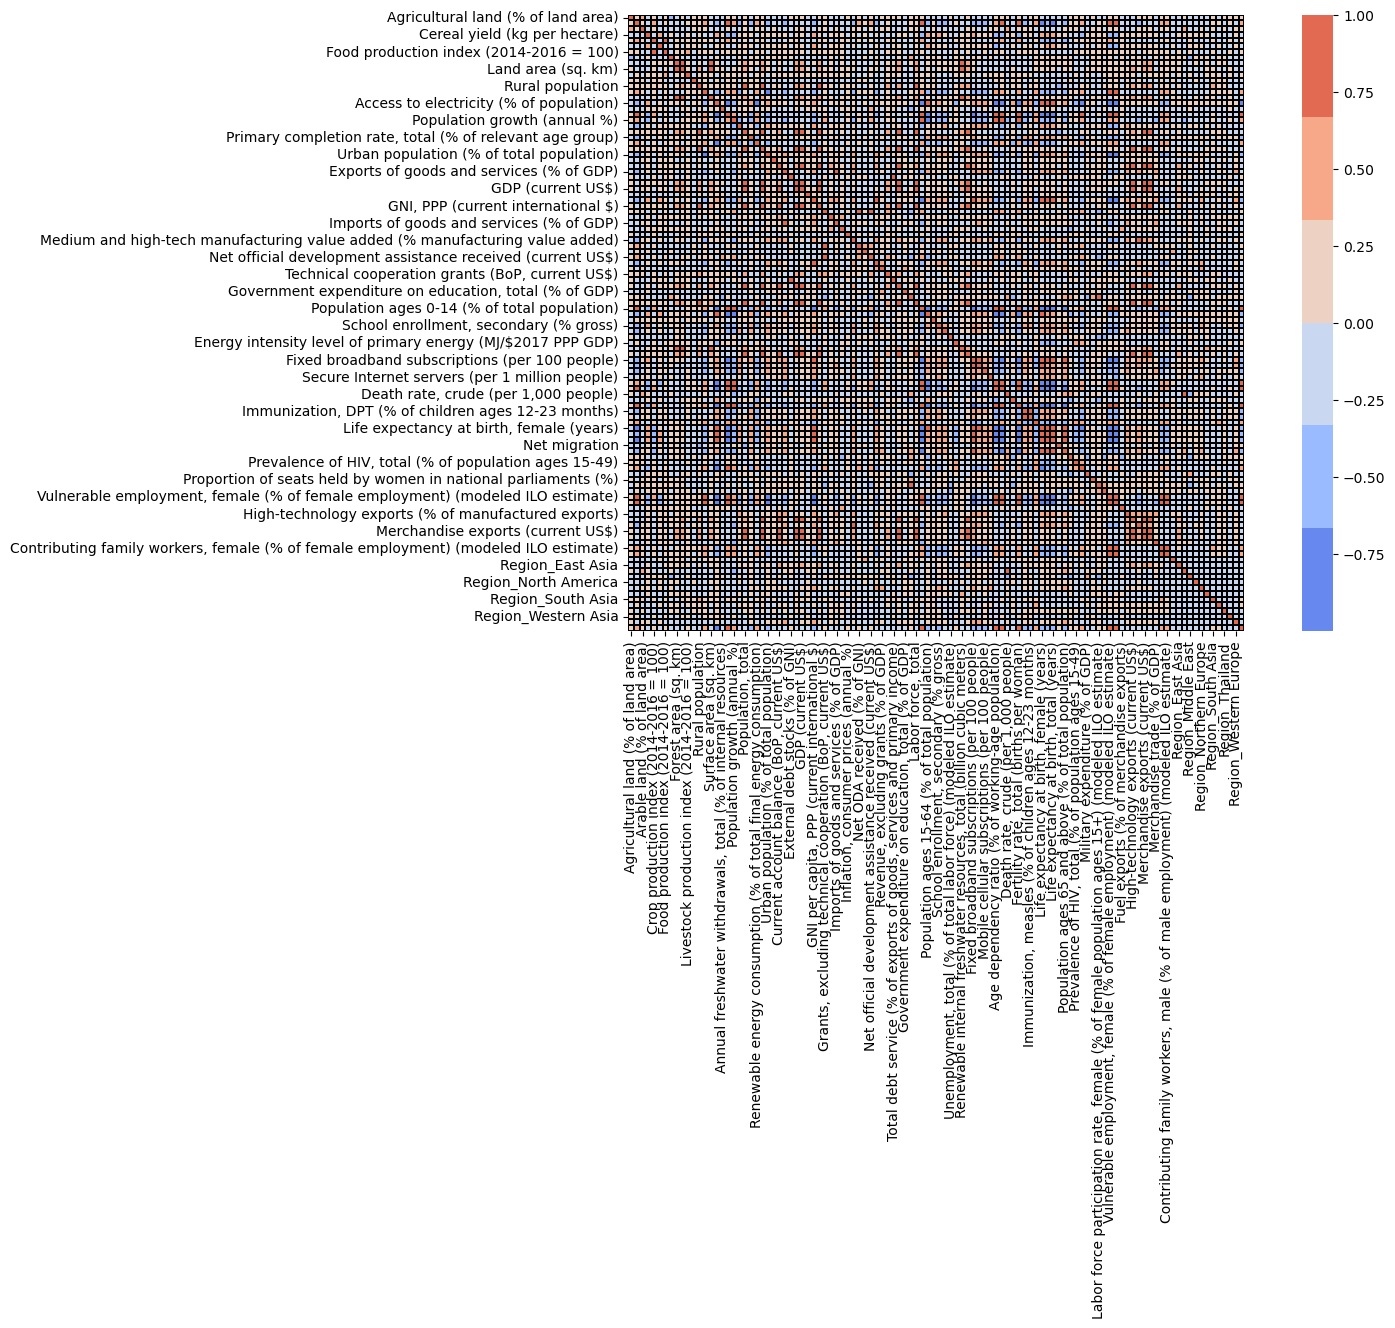

In [196]:
plt.figure(figsize=(15,8))
sns.heatmap(X_train.corr(),
            square=True,
            linewidths=0.25,    
            linecolor=(0,0,0),
            cmap=sns.color_palette("coolwarm"),
            annot=False)
plt.show()

In [197]:
def drop_high_corr_cols_with_target(X, y, threshold=0.8):
    corr = X.corr().abs()
    target_corr = X.apply(lambda col: col.corr(y)).abs()

    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    drop_cols = set()

    for col in upper.columns:
        if col in drop_cols:
            continue
        high_corr = upper[col][upper[col] > threshold].index
        for other in high_corr:
            if other in drop_cols:
                continue
            if target_corr[col] < target_corr[other]:
                drop_cols.add(col)
                break
            else:
                drop_cols.add(other)


    return list(drop_cols)

In [198]:
drop_cols = drop_high_corr_cols(X_train, threshold=0.9)

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [199]:
X_train.shape

(147, 89)

In [200]:
X_test.shape

(37, 89)

# Modeling 

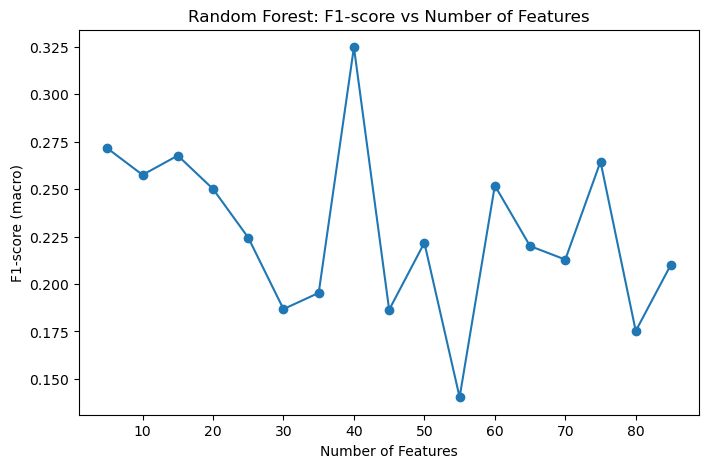

In [201]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

rf_base = RandomForestClassifier(
    n_estimators=500,
    random_state=0,
    class_weight="balanced"
)

rf_base.fit(X_train, y_train)

importances = pd.Series(
    rf_base.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

results = []

for n_features in range(5, len(importances) + 1, 5):
    selected_features = importances.head(n_features).index

    X_tr = X_train[selected_features]
    X_te = X_test[selected_features]

    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=0,
        class_weight="balanced"
    )

    rf.fit(X_tr, y_train)
    y_pred = rf.predict(X_te)

    f1 = f1_score(y_test, y_pred, average="macro")
    results.append((n_features, f1))

results_df = pd.DataFrame(results, columns=["n_features", "f1_macro"])

best_row = results_df.loc[results_df["f1_macro"].idxmax()]
best_n_features = int(best_row["n_features"])
best_f1 = best_row["f1_macro"]

best_features = importances.head(best_n_features).index

X_train = X_train[best_features]
X_test  = X_test[best_features]

plt.figure(figsize=(8, 5))
plt.plot(results_df["n_features"], results_df["f1_macro"], marker="o")
plt.xlabel("Number of Features")
plt.ylabel("F1-score (macro)")
plt.title("Random Forest: F1-score vs Number of Features")
plt.show()

In [202]:
# Function to compute performance classification metrics
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

In [203]:
X_train.shape

(147, 40)

In [204]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=500, random_state=0, class_weight="balanced")
model.fit(X_train, y_train)
#######################################################

# Use model for predicted responses
y_pred = model.predict(X_test)

acc, precision, recall, f1, confusion = evaluate_performance(y_test, y_pred)
print(confusion)
print(acc, precision, recall, f1)

[[1 6 0 0 0]
 [2 8 1 0 0]
 [1 2 2 0 1]
 [0 3 1 0 0]
 [0 4 0 1 4]]
0.40540540540540543 0.37956521739130433 0.32958152958152953 0.32476699770817413


# Performance evaluation

In [205]:
# Get summary of classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         1.0       0.25      0.14      0.18         7
         2.0       0.35      0.73      0.47        11
         3.0       0.50      0.33      0.40         6
         4.0       0.00      0.00      0.00         4
         5.0       0.80      0.44      0.57         9

    accuracy                           0.41        37
   macro avg       0.38      0.33      0.32        37
weighted avg       0.43      0.41      0.38        37

